# Exploration des données (EDA) – Projet fraude pré-sinistre

## 1. Contexte et objectif
Objectif : analyser un jeu de données d'assurance 
et préparer une modélisation visant à prédire la fraude (fraud_reported).

Cette étape couvre :
- la volumétrie,
- la qualité des données,
- les biais et limites,
- les relations entre variables,
- 5 visualisations avec validations statistiques.

## 2. Source des données
Le dataset **insurance_claims.csv** provient de **Mendeley Data** (ABDELRAHIM AQQAD), publié le **22 août 2023** (Version 2), DOI : **10.17632/992mh7dk9y.2**.
Licence : **CC BY 4.0** (réutilisation autorisée avec attribution).

## 3. Chargement et aperçu du jeu de données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

df = pd.read_csv("../data/insurance_claims.csv")
df.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


## 4. Volumétrie et structure des données

In [2]:
df.shape

(1000, 40)

Le jeu de données contient **1000 observations** et **40 variables**.
Chaque ligne représente un sinistre. 
Il s’agit d’un dataset de taille modérée, suffisant pour une analyse exploratoire
et des modèles de machine learning classiques.

In [3]:
df.columns.tolist()

['months_as_customer',
 'age',
 'policy_number',
 'policy_bind_date',
 'policy_state',
 'policy_csl',
 'policy_deductable',
 'policy_annual_premium',
 'umbrella_limit',
 'insured_zip',
 'insured_sex',
 'insured_education_level',
 'insured_occupation',
 'insured_hobbies',
 'insured_relationship',
 'capital-gains',
 'capital-loss',
 'incident_date',
 'incident_type',
 'collision_type',
 'incident_severity',
 'authorities_contacted',
 'incident_state',
 'incident_city',
 'incident_location',
 'incident_hour_of_the_day',
 'number_of_vehicles_involved',
 'property_damage',
 'bodily_injuries',
 'witnesses',
 'police_report_available',
 'total_claim_amount',
 'injury_claim',
 'property_claim',
 'vehicle_claim',
 'auto_make',
 'auto_model',
 'auto_year',
 'fraud_reported',
 '_c39']

Les variables peuvent être regroupées en familles décrivant :
- le contrat d’assurance (prime, franchise, garanties),
- le profil de l’assuré (âge, sexe, profession, niveau d’éducation),
- le contexte du sinistre (date, type, sévérité, dommages)
- les montants déclarés.
Cette structuration facilite l’analyse métier et permet d’identifier
les dimensions potentiellement discriminantes dans la détection de fraude.

La variable cible est **fraud_reported** (binaire), indiquant si un sinistre a été jugé **frauduleux** ou **non frauduleux** après examens (manuels + automatisés).

Particularités / limites :
- Données **anonymisées** : impossible d’identifier les individus (ok pour la confidentialité, mais limite les possibilités d’enrichissement externe via croisement avec d’autres bases clients ou contextuelles,
ce qui restreint certaines analyses avancées réalisables en contexte industriels).
- Risque potentiel de **fuite d’information** : certaines variables pourraient refléter des éléments connus après investigation (à vérifier). Les variables renseignées après investigation doivent être exclues de la modélisation. Cela fausse le modèle. 
- Variable `_c39` non documentée : à investiguer (colonne technique issue de l’export?) et potentiellement supprimer.
- Les variables `insured_*` décrivent le profil socio-démographique de l’assuré.
Elles peuvent introduire des biais statistiques ou éthiques et devront être
utilisées avec prudence, voire exclues, lors de la modélisation.

| Famille de variables | Exemples | Rôle | Pertinence pour la fraude |
|---------------------|----------|------|---------------------------|
| Contrat (policy_*) | policy_annual_premium, deductible | Décrit le contrat | Élevée |
| Assuré (insured_*) | age, occupation | Profil client | Moyenne (biais) |
| Sinistre (incident_*) | type, severity | Contexte du sinistre | Élevée |
| Montants (claim_*) | total_claim_amount | Impact financier | Très élevée |
| Administratif | police_report_available | Processus | Risque de fuite |

In [4]:
df.dtypes.value_counts()

object     21
int64      17
float64     2
Name: count, dtype: int64

On observe :
- **21 variables catégorielles** (`object`) : variables qualitatives décrivant des catégories (ex. type de sinistre, état, profession),
- **17 variables numériques discrètes** (`int64`) : variables entières (ex. âge, nombre de véhicules, nombre de témoins),
- **2 variables numériques continues** (`float64`) : variables quantitatives continues (ex. montants financiers).

- les **variables catégorielles** devront être transformées en valeurs numériques à l’aide d’un **encodage** (par exemple *one-hot encoding* ou encodage ordinal), afin d’être exploitables par les modèles de machine learning ;
- certaines **variables numériques à forte cardinalité** (beaucoup de valeurs différentes, comme des identifiants) devront être analysées avec précaution, car elles peuvent introduire du bruit ou du sur-apprentissage ;
- le jeu de données se prête particulièrement à l’utilisation de **modèles capables de gérer des données mixtes**, tels que les arbres de décision, les forêts aléatoires ou les méthodes de boosting.

## 5. Variable cible et déséquilibre des classes

In [5]:
df["fraud_reported"].value_counts()

fraud_reported
N    753
Y    247
Name: count, dtype: int64

La variable cible `fraud_reported` indique si un sinistre a été jugé **frauduleux (Y)** ou **non frauduleux (N)** après analyse.

La répartition observée est la suivante :
- **N (non frauduleux)** : 753 sinistres  
- **Y (frauduleux)** : 247 sinistres  

In [6]:
df["fraud_reported"].value_counts(normalize=True, dropna=False)

fraud_reported
N    0.753
Y    0.247
Name: proportion, dtype: float64

En proportion, cela représente environ 75 % de non-fraude contre 25 % de fraude.

### Interprétation simple 

- **Proche de 50 / 50**  
  → équilibré.

- **70–80 / 20–30**  
  → déséquilibre modéré.

- **95 / 5 ou 99 / 1**  
  → déséquilibre fort.

Dans notre cas, il s'agit d'un déséquilibre de classes modéré à prendre en compte
lors de la modélisation.

## 6. Qualité des données et premières corrections

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   object 
 4   policy_state                 1000 non-null   object 
 5   policy_csl                   1000 non-null   object 
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   object 
 11  insured_education_level      1000 non-null   object 
 12  insured_occupation           1000 non-null   object 
 13  insured_hobbies    

- La majorité des variables sont **complètement renseignées** (1000 valeurs non nulles).
- Une variable présente des **valeurs manquantes** :
  - `authorities_contacted` : 999 valeurs non nulles → **1 valeur manquante** à traiter lors du pré-processing.
- La colonne `_c39` contient **0 valeur non nulle** : elle est vide et devra être **supprimée**.

Globalement, la qualité des données est **bonne**, avec peu de valeurs manquantes, ce qui est favorable pour la suite du projet.

In [8]:
df.duplicated().sum()

np.int64(0)

La vérification des doublons à l’aide de la méthode `df.duplicated().sum()` ne met en évidence **aucune ligne dupliquée** dans le jeu de données.

Cela signifie que chaque observation correspond à un sinistre unique.  
Aucune action de suppression ou de correction liée aux doublons n’est donc nécessaire à ce stade de l’analyse.

Le nettoyage complet des données sera réalisé **après l’analyse exploratoire** et **avant la modélisation**, afin de :
- conserver une EDA fidèle aux données brutes,
- justifier les choix de traitement (valeurs manquantes, variables inutiles, outliers),
- garantir un pré-traitement reproductible (pipeline).

À ce stade de l’EDA, seules des corrections “sans risque” peuvent être appliquées
(ex. suppression d’une colonne entièrement vide comme `_c39`, conversion des dates),
tandis que le traitement des outliers et des encodages sera défini après les analyses graphiques.

In [9]:
df = df.drop(columns=["_c39"])

In [10]:
df.columns

Index(['months_as_customer', 'age', 'policy_number', 'policy_bind_date',
       'policy_state', 'policy_csl', 'policy_deductable',
       'policy_annual_premium', 'umbrella_limit', 'insured_zip', 'insured_sex',
       'insured_education_level', 'insured_occupation', 'insured_hobbies',
       'insured_relationship', 'capital-gains', 'capital-loss',
       'incident_date', 'incident_type', 'collision_type', 'incident_severity',
       'authorities_contacted', 'incident_state', 'incident_city',
       'incident_location', 'incident_hour_of_the_day',
       'number_of_vehicles_involved', 'property_damage', 'bodily_injuries',
       'witnesses', 'police_report_available', 'total_claim_amount',
       'injury_claim', 'property_claim', 'vehicle_claim', 'auto_make',
       'auto_model', 'auto_year', 'fraud_reported'],
      dtype='object')

In [11]:
df["policy_bind_date"] = pd.to_datetime(df["policy_bind_date"], errors="coerce")
df["incident_date"] = pd.to_datetime(df["incident_date"], errors="coerce")

In [12]:
df[["policy_bind_date", "incident_date"]].dtypes

policy_bind_date    datetime64[ns]
incident_date       datetime64[ns]
dtype: object

In [13]:
df.isna().sum().sort_values(ascending=False).head(10)

authorities_contacted          91
witnesses                       0
incident_state                  0
incident_city                   0
incident_location               0
incident_hour_of_the_day        0
number_of_vehicles_involved     0
property_damage                 0
bodily_injuries                 0
months_as_customer              0
dtype: int64

Les variables `policy_bind_date` et `incident_date` ont été converties au format `datetime64[ns]` afin de permettre des analyses temporelles ultérieures (durées, saisons, évolution dans le temps).

La conversion s’est effectuée sans générer de valeurs manquantes supplémentaires.

## 7. Analyse descriptive des variables numériques

In [14]:
desc_num = df.select_dtypes(include="number").describe().T
desc_num.sort_values("mean", ascending=False)

,count,mean,std,min,25%,50%,75%,max
umbrella_limit,1000.0,1.101000e+06,2.297407e+06,-1000000.00,0.0000,0.0,0.000,10000000.00
policy_number,1000.0,5.462386e+05,2.570630e+05,100804.00,335980.2500,533135.0,759099.750,999435.00
insured_zip,1000.0,5.012145e+05,7.170161e+04,430104.00,448404.5000,466445.5,603251.000,620962.00
total_claim_amount,1000.0,5.276194e+04,2.640153e+04,100.00,41812.5000,58055.0,70592.500,114920.00
vehicle_claim,1000.0,3.792895e+04,1.888625e+04,70.00,30292.5000,42100.0,50822.500,79560.00
capital-gains,1000.0,2.512610e+04,2.787219e+04,0.00,0.0000,0.0,51025.000,100500.00
injury_claim,1000.0,7.433420e+03,4.880952e+03,0.00,4295.0000,6775.0,11305.000,21450.00
property_claim,1000.0,7.399570e+03,4.824726e+03,0.00,4445.0000,6750.0,10885.000,23670.00
auto_year,1000.0,2.005103e+03,6.015861e+00,1995.00,2000.0000,2005.0,2010.000,2015.00
policy_annual_premium,1000.0,1.256406e+03,2.441674e+02,433.33,1089.6075,1257.2,1415.695,2047.59


In [15]:
# Sélection uniquement des variables numériques
desc_num = df.select_dtypes(include="number").describe().T

# Calcul du ratio max / 75% pour détecter les valeurs extrêmes
desc_num["ratio_max_q75"] = desc_num["max"] / desc_num["75%"]

# Tri des variables les plus sujettes aux outliers
desc_num.sort_values("ratio_max_q75", ascending=False).head(10)

,count,mean,std,min,25%,50%,75%,max,ratio_max_q75
umbrella_limit,1000.0,1.101000e+06,2.297407e+06,-1000000.00,0.0000,0.0,0.000,10000000.00,inf
property_claim,1000.0,7.399570e+03,4.824726e+03,0.00,4445.0000,6750.0,10885.000,23670.00,2.174552
capital-gains,1000.0,2.512610e+04,2.787219e+04,0.00,0.0000,0.0,51025.000,100500.00,1.969623
injury_claim,1000.0,7.433420e+03,4.880952e+03,0.00,4295.0000,6775.0,11305.000,21450.00,1.897391
months_as_customer,1000.0,2.039540e+02,1.151132e+02,0.00,115.7500,199.5,276.250,479.00,1.733937
total_claim_amount,1000.0,5.276194e+04,2.640153e+04,100.00,41812.5000,58055.0,70592.500,114920.00,1.627935
vehicle_claim,1000.0,3.792895e+04,1.888625e+04,70.00,30292.5000,42100.0,50822.500,79560.00,1.565448
witnesses,1000.0,1.487000e+00,1.111335e+00,0.00,1.0000,1.0,2.000,3.00,1.500000
age,1000.0,3.894800e+01,9.140287e+00,19.00,32.0000,38.0,44.000,64.00,1.454545
policy_annual_premium,1000.0,1.256406e+03,2.441674e+02,433.33,1089.6075,1257.2,1415.695,2047.59,1.446350


Le tableau `df.describe().T` fournit des statistiques descriptives pour chaque variable numérique.  
Afin de le rendre exploitable dans une démarche d’EDA, on procède à une analyse ciblée.

### Méthode utilisée

1. **Identifier les variables les plus importantes en termes d’ordre de grandeur**  
   → tri des variables par moyenne (`mean`) décroissante.  
   Cela permet de repérer les variables financières ou quantitatives dominantes.

2. **Évaluer la dispersion et la présence potentielle d’outliers**  
   → comparaison entre la valeur maximale (`max`) et le troisième quartile (`75%`) à l’aide du ratio :

   `ratio_max_q75 = max / 75%`

### Interprétation simple du ratio `max / 75%`

- **Ratio proche de 1**  
  → distribution stable, peu ou pas de valeurs extrêmes.

- **Ratio > 1.5**  
  → présence probable d’outliers (quelques valeurs très élevées).

- **Ratio très élevé ou infini**  
  → valeur aberrante, distribution très asymétrique ou variable nécessitant une attention particulière
  (transformation, plafonnement, ou exclusion éventuelle).

### Variables particulièrement utiles à commenter avant la modélisation

Certaines variables ressortent à la fois :
- par leur **niveau moyen élevé**,
- par leur **forte dispersion**,
- et par leur **importance métier** dans un contexte de fraude à l’assurance.

Il s’agit notamment de :
- `total_claim_amount`
- `vehicle_claim`
- `property_claim`
- `injury_claim`
- `umbrella_limit`

Ces variables :
- portent des **montants financiers significatifs**,
- présentent souvent des **distributions asymétriques**,
- peuvent fortement **influencer l’apprentissage des modèles**.

Elles devront faire l’objet de traitements spécifiques lors de la phase de préparation des données
(log-transformations, gestion des valeurs extrêmes, normalisation éventuelle).

## 8. Repérage des variables qualitatives

Le jeu de données contient un nombre important de variables qualitatives (catégorielles), notamment :

- des variables liées au **contrat** (`policy_state`, `policy_csl`),
- au **profil de l’assuré** (`insured_sex`, `insured_education_level`, `insured_occupation`, `insured_hobbies`),
- au **contexte du sinistre** (`incident_type`, `collision_type`, `incident_severity`),
- au **processus administratif** (`authorities_contacted`, `police_report_available`).

Ces variables :
- ne nécessitent pas de statistiques descriptives numériques,
- seront principalement analysées **via des visualisations** (répartition des modalités, comparaison avec la variable cible),
- pourront présenter des enjeux de **biais** ou de **fuite d’information**, qui seront discutés lors de l’interprétation.

L’analyse détaillée de ces variables sera donc réalisée dans la section de visualisation exploratoire.

## 9. Conclusion de l’EDA tabulaire

L’analyse exploratoire initiale a permis de :

- vérifier la structure globale du jeu de données,
- identifier et traiter les éventuels problèmes de qualité (colonne vide, types de données),
- analyser la distribution des variables numériques et repérer la présence potentielle de valeurs extrêmes,
- confirmer la variable cible (`fraud_reported`) et son déséquilibre modéré,
- repérer les principales variables quantitatives et qualitatives d’intérêt métier.

Le jeu de données apparaît globalement cohérent et exploitable pour la suite de l’analyse.
Aucune anomalie bloquante n’a été identifiée à ce stade.

## 10. Visualisation exploratoire des données

### Transition vers la visualisation exploratoire

Les analyses réalisées jusqu’à présent reposent essentiellement sur des statistiques descriptives tabulaires.
Si celles-ci permettent une première compréhension des données, elles restent limitées pour :

- analyser finement les distributions,
- comparer les variables explicatives à la variable cible,
- détecter visuellement les asymétries, regroupements ou comportements atypiques,
- explorer les relations entre variables, notamment dans un contexte de fraude.

La prochaine étape consiste donc à réaliser une **visualisation exploratoire des données**, en particulier :

- l’étude graphique des variables numériques clés (distributions, outliers),
- l’analyse des variables qualitatives (répartition des modalités),
- la comparaison systématique des variables avec la variable cible `fraud_reported`.

Ces visualisations permettront d’approfondir l’interprétation métier et de préparer les choix méthodologiques pour la phase de modélisation.

### Choix des outils de visualisation

Les visualisations exploratoires présentées ci-dessous sont réalisées principalement avec la bibliothèque Seaborn, choisie pour sa lisibilité et son adéquation aux analyses statistiques en phase d’EDA.  
Matplotlib est utilisé en complément pour certains ajustements graphiques.

### Graphique 1 – Distribution du montant total du sinistre selon la fraude

**Objectif :**  

Analyser la relation entre le montant total du sinistre (`total_claim_amount`) et la variable cible `fraud_reported`, afin d’identifier d’éventuelles différences de distribution entre les sinistres frauduleux et non frauduleux.

Le montant total du sinistre est une variable numérique continue.  
Un boxplot est particulièrement adapté pour comparer les distributions de cette variable selon une variable catégorielle binaire, car il permet de visualiser la médiane, la dispersion et la présence d’éventuels outliers.

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

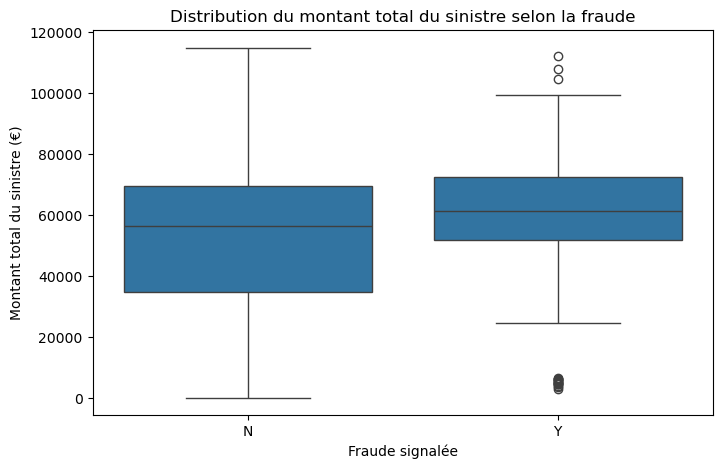

In [17]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="fraud_reported",
    y="total_claim_amount",
    data=df,
    order=["N", "Y"]
)

plt.title("Distribution du montant total du sinistre selon la fraude")
plt.xlabel("Fraude signalée")
plt.ylabel("Montant total du sinistre (€)")

plt.show()

**Lecture statistique :**  

Le boxplot compare la distribution de `total_claim_amount` entre les sinistres non frauduleux (N) et frauduleux (Y) à travers la médiane, les quartiles et la dispersion.  
La médiane des montants apparaît légèrement plus élevée pour les sinistres frauduleux, mais les distributions présentent un chevauchement important et des valeurs élevées dans les deux classes.

**Choix de représentation et adaptation :**  

Une première version du graphique incluait un nuage de points (stripplot) afin de visualiser la densité des observations.  
Cependant, la variable cible étant déséquilibrée (~75 % de non-fraude contre ~25 % de fraude), la classe `N` apparaissait mécaniquement plus dense, ce qui pouvait induire une lecture visuelle biaisée.  
Une représentation plus robuste (boxplot seul) a donc été retenue pour faciliter une comparaison objective entre les deux classes.

**Implications pour la suite :** 

Ces résultats indiquent que le montant total du sinistre constitue une variable informative mais faiblement discriminante lorsqu’elle est considérée isolément.  
Cela justifie l’exploration de variables complémentaires liées à la gravité du sinistre et au contexte déclaratif afin d’améliorer la capacité de détection de la fraude lors de la modélisation.

Dans la continuité de l’analyse des montants financiers, la visualisation suivante s’intéresse à une variable décrivant l’intensité du sinistre.  
La variable `incident_severity` est analysée en priorité parmi les variables catégorielles car elle est directement liée à l’ampleur du dommage déclaré et peut structurer les mécanismes de fraude.

### Graphique 2 – Gravité du sinistre et fraude (volumes et taux)

**Objectif :**  

Évaluer si la gravité du sinistre (`incident_severity`) est associée à la fraude (`fraud_reported`).  
Deux lectures complémentaires sont proposées :  
1) une lecture en **volumes** (effectifs bruts),  
2) une lecture en **taux de fraude** (proportion de `Y`), plus adaptée en présence d’un déséquilibre de classes.

#### Version 1 – Répartition en volumes (effectifs bruts)

Cette première visualisation compare le **nombre** de sinistres frauduleux et non frauduleux selon la gravité.  
Elle permet de contextualiser les volumes, mais reste influencée par le déséquilibre de la variable cible.

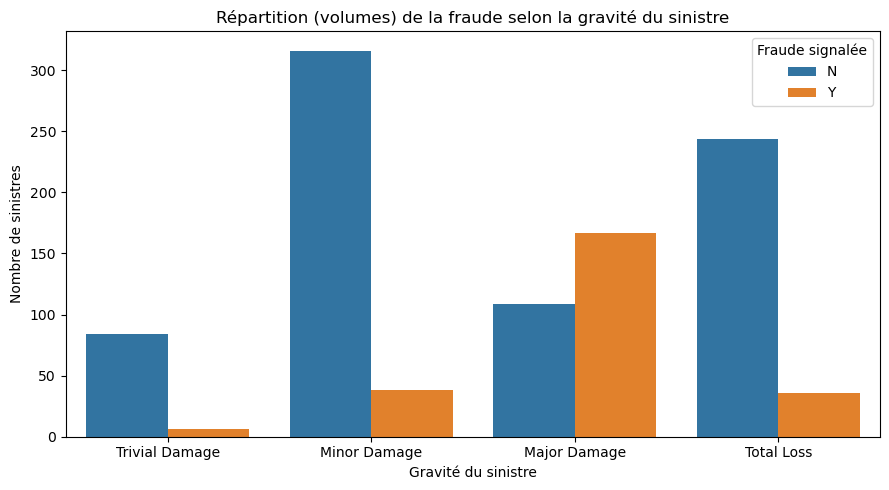

In [18]:
order_sev = ["Trivial Damage", "Minor Damage", "Major Damage", "Total Loss"]

plt.figure(figsize=(9, 5))
sns.countplot(
    x="incident_severity",
    hue="fraud_reported",
    data=df,
    order=order_sev,
    hue_order=["N", "Y"]
)

plt.title("Répartition (volumes) de la fraude selon la gravité du sinistre")
plt.xlabel("Gravité du sinistre")
plt.ylabel("Nombre de sinistres")
plt.legend(title="Fraude signalée")
plt.tight_layout()
plt.show()

**Lecture (volumes) :**  

Les effectifs bruts montrent que la plupart des sinistres appartiennent aux catégories `Minor Damage`, `Total Loss` et `Major Damage`.  
Cependant, la comparaison directe des barres `N` et `Y` doit être interprétée avec prudence, car la base de données est globalement déséquilibrée (~75 % N vs ~25 % Y).

Afin de fiabiliser l’interprétation, on vérifie le nombre d’observations disponibles par niveau de gravité.

In [19]:
df["incident_severity"].value_counts()

incident_severity
Minor Damage      354
Total Loss        280
Major Damage      276
Trivial Damage     90
Name: count, dtype: int64

**Contrôle des effectifs :**  

Les catégories présentent des effectifs non négligeables (ex. `Minor Damage`, `Total Loss`, `Major Damage`) ; la catégorie `Trivial Damage` est plus rare mais reste interprétable.  
Cela permet de comparer les tendances, tout en restant prudent sur les catégories les moins représentées.

#### Version 2 – Taux de fraude (proportion de `Y`)

Pour dépasser la lecture en effectifs et tenir compte du déséquilibre de classes, on calcule ici le **taux de fraude** par niveau de gravité :  
taux = (nombre de Y) / (nombre total dans la catégorie).
Cette représentation permet de comparer directement la probabilité de fraude selon chaque niveau de gravité du sinistre.

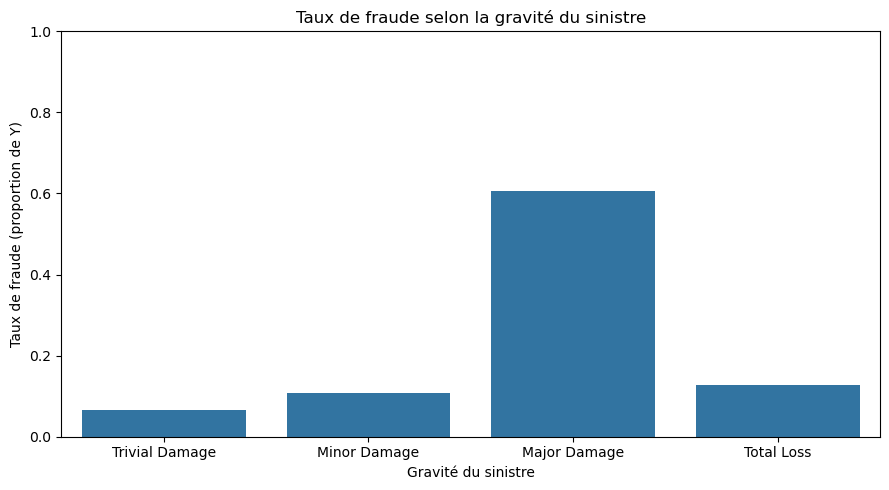

In [20]:
order_sev = ["Trivial Damage", "Minor Damage", "Major Damage", "Total Loss"]

fraud_rate = (
    df.assign(fraud_bin=(df["fraud_reported"] == "Y").astype(int))
      .groupby("incident_severity")["fraud_bin"]
      .mean()
      .reindex(order_sev)
      .reset_index()
)

plt.figure(figsize=(9, 5))
sns.barplot(data=fraud_rate, x="incident_severity", y="fraud_bin")

plt.title("Taux de fraude selon la gravité du sinistre")
plt.xlabel("Gravité du sinistre")
plt.ylabel("Taux de fraude (proportion de Y)")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

**Lecture (taux) :**  

Le taux de fraude varie fortement selon la gravité du sinistre.  
La catégorie `Major Damage` présente un taux de fraude nettement supérieur aux autres catégories, ce qui suggère une association marquée entre ce niveau de gravité et la fraude dans ce jeu de données.

**Interprétation métier :**  

Un sinistre déclaré comme “Major Damage” laisse généralement une plus grande marge d’appréciation dans l’évaluation des dommages (pièces à remplacer, niveau de réparation, immobilisation du véhicule).  
Cette complexité peut faciliter des déclarations exagérées ou difficiles à vérifier, ce qui augmente le risque de fraude.  
À l’inverse, les sinistres de faible gravité (“Trivial” ou “Minor Damage”), comme de petites rayures ou des chocs légers, sont plus simples à constater et à contrôler, et offrent moins d’opportunités de surévaluation.

**Conséquences pour la modélisation :**

Même si le signal est fort en proportion, l’interprétation doit tenir compte des effectifs par catégorie (catégories rares → estimation moins stable).  
La variable `incident_severity` apparaît néanmoins comme un candidat pertinent pour la modélisation, potentiellement en interaction avec des variables financières (`total_claim_amount`, `injury_claim`, etc.).

Après l’analyse du rapport de police, on approfondit la dimension **déclarative et administrative** via la variable `authorities_contacted`.  
Cette variable décrit quelles autorités ont été contactées suite au sinistre (ex. police, ambulance, pompiers). Elle peut refléter le niveau de formalisation et la traçabilité du sinistre, et potentiellement différencier certains profils de fraude.

### Graphique 3 – Autorités contactées et fraude (volumes et taux)

**Objectif :**  

Évaluer si la fraude (`fraud_reported`) est associée aux autorités contactées (`authorities_contacted`).  
Deux lectures sont proposées :  
1) **volumes** (effectifs bruts),  
2) **taux de fraude** (proportion de `Y`) pour comparer correctement les modalités malgré le déséquilibre de classes.

Avant visualisation, on vérifie les modalités de `authorities_contacted` et la présence éventuelle de valeurs manquantes ou codées avec `?`.

In [21]:
df["authorities_contacted"].value_counts(dropna=False)

authorities_contacted
Police       292
Fire         223
Other        198
Ambulance    196
NaN           91
Name: count, dtype: int64

On observe la présence de valeurs manquantes (`NaN`) pour la variable `authorities_contacted`.  
Ces observations correspondent à des informations non renseignées et ne permettent pas d’identifier l’autorité effectivement contactée.  
Afin d’éviter toute ambiguïté dans l’interprétation des comparaisons, ces valeurs manquantes sont exclues des visualisations suivantes.

In [22]:
df_auth = df.copy()

# Exclut les "NaN" 
df_auth = df[df["authorities_contacted"].notna()].copy()

df_auth["authorities_contacted"].value_counts()

authorities_contacted
Police       292
Fire         223
Other        198
Ambulance    196
Name: count, dtype: int64

**Contrôle des effectifs :**

Les différentes modalités de la variable `authorities_contacted` présentent des effectifs comparables et suffisants pour permettre une analyse en proportion.  
Aucune catégorie n’apparaît marginale, ce qui limite le risque d’instabilité des taux de fraude calculés par modalité.  
L’interprétation des différences observées peut ainsi être menée avec un niveau de confiance raisonnable, tout en veillant aux écarts de taille entre catégories.

#### Version 1 – Volumes (effectifs bruts)

Cette visualisation compare le nombre de sinistres frauduleux et non frauduleux selon les autorités contactées.  
Elle décrit les volumes, mais doit être complétée par une lecture en proportion (taux), car la classe `N` est majoritaire dans le dataset.

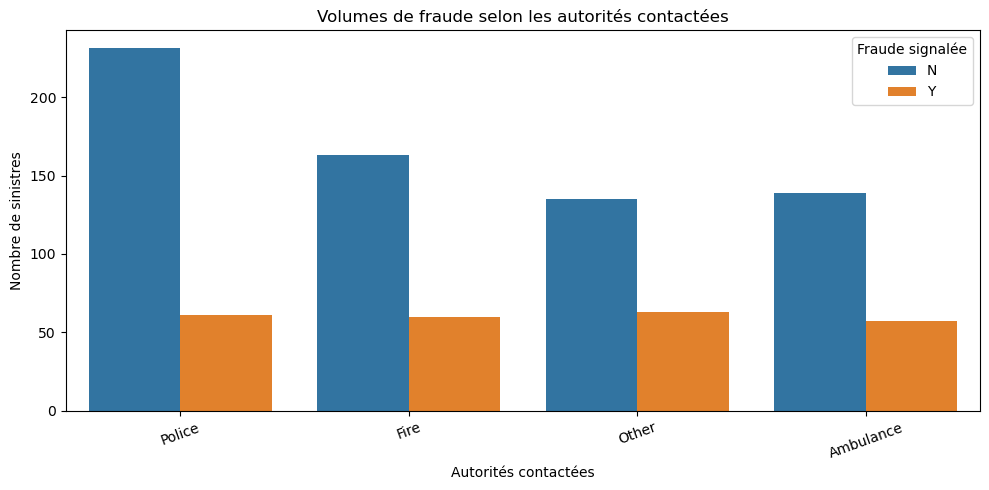

In [23]:
order_auth = df_auth["authorities_contacted"].value_counts().index

plt.figure(figsize=(10, 5))
sns.countplot(
    x="authorities_contacted",
    hue="fraud_reported",
    data=df_auth,
    order=order_auth,
    hue_order=["N", "Y"]
)

plt.title("Volumes de fraude selon les autorités contactées")
plt.xlabel("Autorités contactées")
plt.ylabel("Nombre de sinistres")
plt.legend(title="Fraude signalée")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**Lecture (volumes) :**

Les effectifs bruts montrent que les sinistres impliquant la police sont les plus fréquents, tandis que les autres autorités (pompiers, ambulance, autres) présentent des volumes plus comparables entre eux.  
Dans toutes les modalités, les sinistres non frauduleux restent majoritaires, ce qui reflète le déséquilibre global de la variable cible.  
Cette lecture en volume ne permet toutefois pas d’évaluer le risque de fraude par modalité ; l’analyse est donc complétée par une lecture en proportion (taux de fraude).

#### Version 2 – Taux de fraude (proportion de `Y`)

Cette représentation permet de comparer directement la probabilité de fraude selon les autorités contactées.

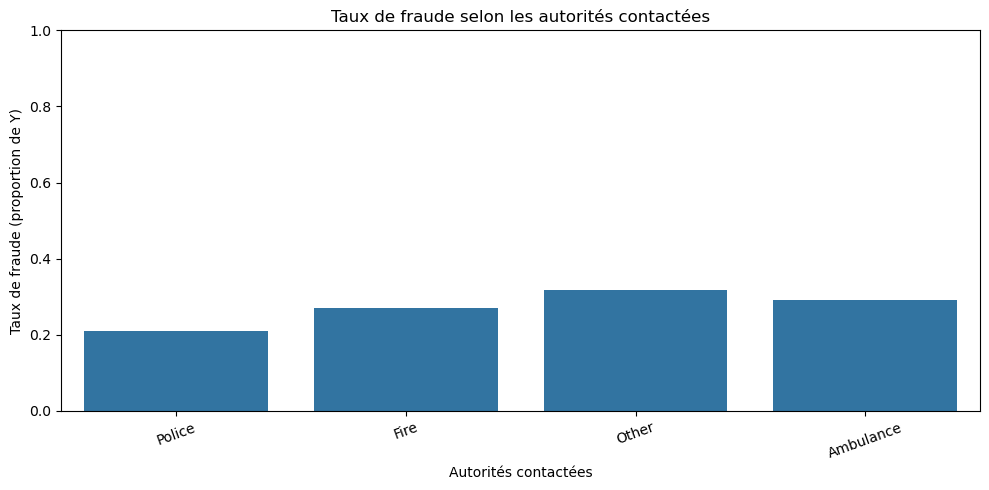

In [24]:
fraud_rate_auth = (
    df_auth.assign(fraud_bin=(df_auth["fraud_reported"] == "Y").astype(int))
           .groupby("authorities_contacted")["fraud_bin"]
           .mean()
           .reindex(order_auth)
           .reset_index()
)

plt.figure(figsize=(10, 5))
sns.barplot(data=fraud_rate_auth, x="authorities_contacted", y="fraud_bin")

plt.title("Taux de fraude selon les autorités contactées")
plt.xlabel("Autorités contactées")
plt.ylabel("Taux de fraude (proportion de Y)")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**Lecture (taux) :**

Le taux de fraude varie modérément selon les autorités contactées, sans rupture très marquée entre les catégories.  
Certaines modalités (par exemple *Other* ou *Ambulance*) présentent des taux légèrement plus élevés que *Police*, ce qui suggère un signal potentiel mais de faible intensité.  
Ces écarts doivent toutefois être interprétés avec prudence, en tenant compte des effectifs par modalité : les catégories moins fréquentes peuvent produire des estimations de taux plus instables.

**Interprétation métier :**

Le type d’autorité contactée peut refléter la gravité perçue du sinistre, la nature de l’événement et le degré de formalisation de la déclaration.  
Par exemple, certains sinistres impliquent systématiquement des autorités spécifiques (police, secours), tandis que d’autres peuvent être gérés de manière plus informelle.  
Ces différences de contexte peuvent influencer les modalités de déclaration et de contrôle, et ainsi jouer un rôle indirect dans le risque de fraude, notamment en interaction avec la gravité du sinistre et les montants déclarés.

**Conséquences pour la modélisation :**

La variable `authorities_contacted` peut constituer un candidat pertinent pour la modélisation, car elle capture une dimension déclarative et administrative complémentaire aux variables de gravité et financières.  
Elle pourra être combinée à d’autres variables de contexte (rapport de police, témoins, blessures) afin d’explorer des interactions susceptibles d’améliorer la détection de profils à risque.

Après l’analyse des montants (Graphique 1), de l’intensité du sinistre (Graphique 2) et d’un indicateur déclaratif (Graphique 3), on analyse une variable de typologie du sinistre : incident_type.
L’objectif est d’identifier si certains types d’événements sont associés à une probabilité de fraude plus élevée.

### Graphique 4 – Type de sinistre et fraude (taux trié)

**Objectif :**  

Comparer la probabilité de fraude selon le type de sinistre en calculant le taux

Avant visualisation, on vérifie les modalités de `incident_type` et la présence éventuelle de valeurs manquantes ou codées comme inconnues.

In [25]:
df["incident_type"].value_counts(dropna=False)

incident_type
Multi-vehicle Collision     419
Single Vehicle Collision    403
Vehicle Theft                94
Parked Car                   84
Name: count, dtype: int64

**Contrôle des effectifs :**

La variable `incident_type` comporte quatre modalités principales, avec des effectifs relativement équilibrés pour les collisions multi-véhicules et mono-véhicule, et des effectifs plus faibles pour les catégories *Vehicle Theft* et *Parked Car*.  

Ces différences d’effectifs seront prises en compte lors de l’interprétation des taux de fraude : les catégories les moins représentées peuvent produire des estimations plus sensibles aux variations.

In [26]:
fraud_rate_it = (
    df.assign(fraud_bin=(df["fraud_reported"] == "Y").astype(int))
      .groupby("incident_type")["fraud_bin"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

fraud_rate_it

,incident_type,fraud_bin
0,Single Vehicle Collision,0.290323
1,Multi-vehicle Collision,0.272076
2,Parked Car,0.095238
3,Vehicle Theft,0.085106


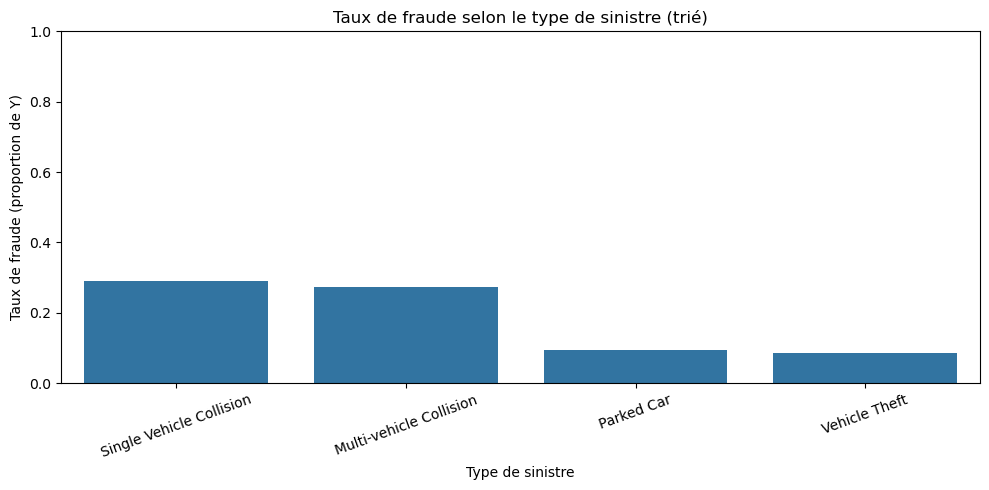

In [27]:
plt.figure(figsize=(10, 5))
sns.barplot(data=fraud_rate_it, x="incident_type", y="fraud_bin")

plt.title("Taux de fraude selon le type de sinistre (trié)")
plt.xlabel("Type de sinistre")
plt.ylabel("Taux de fraude (proportion de Y)")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**Lecture (taux) :**

Le taux de fraude varie nettement selon le type de sinistre.  
Les collisions (mono-véhicule et multi-véhicules) présentent les taux les plus élevés (≈ 27–29 %), alors que les sinistres de type *Parked Car* et *Vehicle Theft* affichent des taux beaucoup plus faibles (≈ 8–10 %).  
L’écart observé (environ un facteur 3 entre les catégories extrêmes) suggère que `incident_type` contient une information utile pour différencier les profils de sinistres dans ce jeu de données.

**Interprétation métier :**

Les résultats mettent principalement en évidence un **effet “collision”** : les collisions mono-véhicule et multi-véhicules présentent des taux de fraude proches. Cela suggère que c’est avant tout la survenue d’un accident — et la variabilité possible des dommages et des circonstances — qui est associée à la fraude, davantage que le nombre de véhicules impliqués.

Dans les situations de collision, l’évaluation des circonstances (perte de contrôle, vitesse, conditions météorologiques, responsabilités) et des dommages peut laisser une marge d’interprétation importante, que l’accident implique un ou plusieurs véhicules. Cette complexité peut faciliter des déclarations exagérées ou des scénarios arrangés.

À l’inverse, les sinistres de type *Vehicle Theft* ou *Parked Car* correspondent plus souvent à des événements relativement binaires (le véhicule est volé ou non, le véhicule était stationné ou non) et généralement plus simples à documenter. Cette moindre ambiguïté peut limiter certaines opportunités de fraude.

**Conséquences pour la modélisation :**

Compte tenu des écarts marqués de taux de fraude entre modalités, `incident_type` apparaît comme une variable explicative pertinente.  
Elle pourra être intégrée au modèle et testée en interaction avec la gravité (`incident_severity`) et les variables financières (`total_claim_amount`, `vehicle_claim`, etc.), afin d’évaluer si certains profils “type × gravité × montant” sont particulièrement associés à la fraude.

*Remarque : les catégories les moins fréquentes peuvent produire des taux légèrement moins stables, mais l’écart observé reste important.*

Après l’analyse du montant, de la gravité, des autorités contactées et du type de sinistre, on explore une variable plus factuelle décrivant le contexte de l’accident : `number_of_vehicles_involved`.

L’objectif est de vérifier si la probabilité de fraude varie selon la complexité apparente du sinistre (1 véhicule vs plusieurs).

### Graphique 5 – Nombre de véhicules impliqués et fraude (taux)

**Objectif :**  

Calculer le taux de fraude par nombre de véhicules impliqués.

Avant visualisation, on vérifie les valeurs possibles de `number_of_vehicles_involved` et les effectifs associés, afin d’interpréter les taux avec prudence (modalités rares → taux moins stables).

In [28]:
df["number_of_vehicles_involved"].value_counts(dropna=False).sort_index()

number_of_vehicles_involved
1    581
2     30
3    358
4     31
Name: count, dtype: int64

**Contrôle des valeurs et des effectifs :**

La variable `number_of_vehicles_involved` prend ici 4 valeurs (1 à 4 véhicules).  
On observe une forte hétérogénéité des effectifs : les modalités **1 véhicule (581)** et **3 véhicules (358)** sont largement majoritaires, tandis que **2 véhicules (30)** et **4 véhicules (31)** sont très peu représentées.

Les taux de fraude calculés pour **2** et **4** véhicules devront donc être interprétés avec prudence (estimation plus sensible au hasard / aux variations).

In [29]:
# Ordre naturel des modalités (1,2,3,4) + effectifs par modalité
order_veh = sorted(df["number_of_vehicles_involved"].dropna().unique())

veh_stats = (
    df.assign(fraud_bin=(df["fraud_reported"] == "Y").astype(int))
      .groupby("number_of_vehicles_involved")
      .agg(
          fraud_rate=("fraud_bin", "mean"),
          n=("fraud_bin", "size")
      )
      .reindex(order_veh)
      .reset_index()
)

veh_stats

,number_of_vehicles_involved,fraud_rate,n
0,1,0.228916,581
1,2,0.300000,30
2,3,0.262570,358
3,4,0.354839,31


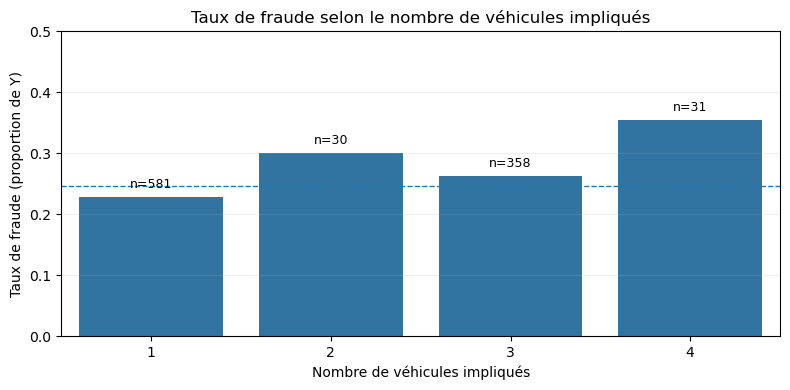

In [30]:
plt.figure(figsize=(8, 4))
ax = sns.barplot(data=veh_stats, x="number_of_vehicles_involved", y="fraud_rate")

# Axe Y plus lisible (au lieu de 0-1)
ymax = max(0.5, veh_stats["fraud_rate"].max() + 0.05)
ax.set_ylim(0, ymax)

# Ligne de référence : taux moyen global
global_rate = (df["fraud_reported"] == "Y").mean()
ax.axhline(global_rate, linestyle="--", linewidth=1)

# Affiche les effectifs au-dessus des barres
for i, row in veh_stats.iterrows():
    ax.text(i, row["fraud_rate"] + 0.01, f'n={int(row["n"])}', ha="center", va="bottom", fontsize=9)

plt.title("Taux de fraude selon le nombre de véhicules impliqués")
plt.xlabel("Nombre de véhicules impliqués")
plt.ylabel("Taux de fraude (proportion de Y)")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

En complément, on affiche les volumes par modalité afin de contextualiser les taux (un taux élevé sur une modalité rare peut être moins stable).

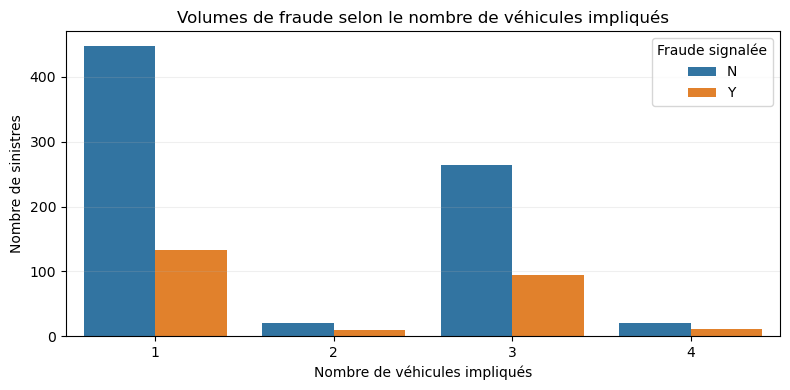

In [31]:
plt.figure(figsize=(8, 4))
ax = sns.countplot(
    data=df,
    x="number_of_vehicles_involved",
    order=order_veh,
    hue="fraud_reported",
    hue_order=["N", "Y"]
)

plt.title("Volumes de fraude selon le nombre de véhicules impliqués")
plt.xlabel("Nombre de véhicules impliqués")
plt.ylabel("Nombre de sinistres")
plt.legend(title="Fraude signalée")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

**Lecture (taux) :**

Le taux de fraude varie selon le nombre de véhicules impliqués.  
On observe un taux plus faible pour les sinistres à **1 véhicule** et un taux plus élevé pour **2 véhicules** et **4 véhicules**.  
Cependant, ces modalités **2** et **4 véhicules** reposent sur des effectifs très faibles (**n≈30–31**), ce qui rend leurs taux plus **instables** et à interpréter avec prudence.

En pratique, l’information la plus robuste provient des catégories les plus représentées (**1 véhicule** et **3 véhicules**), qui montrent des taux proches.

**Interprétation métier :**

Le nombre de véhicules peut refléter la **complexité** de l’événement et le niveau d’incertitude sur les circonstances (responsabilités, enchaînement des dommages, témoignages, constats).  
Cette complexité peut théoriquement ouvrir davantage d’opportunités de fraude (déclarations exagérées, dommages difficilement attribuables).

Néanmoins, dans ces données, les taux élevés observés pour **2** et **4 véhicules** doivent être relativisés car ces catégories sont **rares**. Il est donc possible que l’écart reflète surtout un **effet d’échantillonnage** plutôt qu’un mécanisme métier stable.

**Conséquences pour la modélisation :**

La variable `number_of_vehicles_involved` peut être intégrée au modèle, mais son signal doit être évalué avec prudence compte tenu des modalités rares.  
Cette variable peut aussi interagir avec la typologie du sinistre (`incident_type`) et la gravité (`incident_severity`) pour mieux capter des profils de fraude.

### Limites et pistes exploratoires non retenues

Une analyse exploratoire de la dimension temporelle a été réalisée à partir de la date du sinistre (`incident_date`), en agrégeant les données au niveau mensuel afin d’identifier d’éventuels effets de saisonnalité sur le taux de fraude.

Cette exploration n’a pas été retenue parmi les visualisations principales, car la période couverte par le jeu de données est courte et les effectifs par mois sont très déséquilibrés, avec certains mois reposant sur un nombre très limité d’observations.  
Dans ce contexte, les variations observées du taux de fraude sont susceptibles de refléter une instabilité statistique plutôt qu’un effet temporel robuste.

La dimension temporelle pourra néanmoins être réexplorée ultérieurement si des données couvrant une période plus longue deviennent disponibles.

## 11. Validation statistique des constats (tests)

Les visualisations exploratoires précédentes mettent en évidence des écarts de taux et de distributions entre les sinistres frauduleux et non frauduleux.  
Afin d’évaluer si ces différences sont statistiquement significatives (et non dues au hasard d’échantillonnage), l’EDA est complétée par des tests inférentiels.

- **χ² d’indépendance** pour tester l’association entre la cible `fraud_reported` et des variables **catégorielles** (`incident_severity`, `incident_type`, `number_of_vehicles_involved`).  
  Taille d’effet : **V de Cramér**.
- **Mann–Whitney U** pour comparer la distribution d’une variable **numérique** (`total_claim_amount`) entre deux groupes indépendants (fraude vs non fraude), sans hypothèse de normalité.  
  Taille d’effet : **Cliff’s delta**.

Au-delà de la *p-value*, les tailles d’effet permettent d’apprécier l’ampleur pratique des différences observées, en perspective de la modélisation.


In [32]:
# ============================================================
# Fonctions utilitaires pour la validation statistique
# (χ² + V de Cramér, Mann–Whitney + Cliff's delta)
# ============================================================

from IPython.display import display, Markdown

# ------------------------------------------------------------
# V de Cramér : mesure de la force de l'association (χ²)
# ------------------------------------------------------------
def cramers_v_from_chi2(chi2, n, r, k):
    """
    Calcule le V de Cramér à partir de la statistique χ².

    chi2 : valeur du χ²
    n    : taille totale de l'échantillon
    r,k  : dimensions du tableau de contingence
    """
    denom = n * min(r - 1, k - 1)
    return np.sqrt(chi2 / denom) if denom > 0 else np.nan


# ------------------------------------------------------------
# Test χ² d'indépendance + taille d'effet + contrôles
# ------------------------------------------------------------
def chi2_test_with_effect(df, x, y="fraud_reported"):
    """
    Réalise un test du χ² entre une variable catégorielle x
    et la variable cible y (fraude).

    Retourne :
    - tableau de contingence
    - χ², p-value, ddl
    - V de Cramér (taille d'effet)
    - diagnostics sur les effectifs attendus
    """
    # Tableau de contingence observé
    tab = pd.crosstab(df[x], df[y])

    # Test χ² d'indépendance
    chi2, p, dof, expected = stats.chi2_contingency(tab)

    # Paramètres nécessaires au V de Cramér
    n = tab.to_numpy().sum()
    r, k = tab.shape
    v = cramers_v_from_chi2(chi2, n, r, k)

    # Contrôle des conditions du χ²
    expected_min = expected.min()
    expected_lt5 = int((expected < 5).sum())
    expected_pct_lt5 = expected_lt5 / expected.size

    return {
        "variable": x,
        "table": tab,
        "chi2": chi2,
        "p_value": p,
        "dof": dof,
        "n": n,
        "cramers_v": v,
        "expected_min": expected_min,
        "expected_lt5": expected_lt5,
        "expected_pct_lt5": expected_pct_lt5
    }


# ------------------------------------------------------------
# Cliff's delta : taille d'effet non paramétrique
# ------------------------------------------------------------
def cliffs_delta(x, y):
    """
    Cliff's delta mesure à quel point les valeurs de x
    tendent à être plus grandes que celles de y.

    Valeur comprise entre -1 et 1 :
    0   -> pas de différence
    +1  -> x toujours > y
    -1  -> x toujours < y
    """
    x = np.asarray(x)
    y = np.asarray(y)

    # Suppression des valeurs manquantes
    x = x[~np.isnan(x)]
    y = y[~np.isnan(y)]

    # Comparaison pairwise (suffisant pour ~1000 obs)
    diff = x[:, None] - y[None, :]

    return (np.sum(diff > 0) - np.sum(diff < 0)) / (x.size * y.size)


# ------------------------------------------------------------
# Test Mann–Whitney + Cliff's delta
# ------------------------------------------------------------
def mannwhitney_with_effect(df, num_var, y="fraud_reported",
                            group_Y="Y", group_N="N"):
    """
    Compare la distribution d'une variable numérique
    entre fraude (Y) et non fraude (N).

    Retourne :
    - U de Mann–Whitney
    - p-value
    - Cliff's delta
    - tailles d'échantillon et médianes
    """
    # Séparation des deux groupes
    x = df.loc[df[y] == group_Y, num_var].dropna().values
    z = df.loc[df[y] == group_N, num_var].dropna().values

    # Test non paramétrique
    u, p = stats.mannwhitneyu(x, z, alternative="two-sided")

    # Taille d'effet
    d = cliffs_delta(x, z)

    return {
        "variable": num_var,
        "n_Y": len(x),
        "n_N": len(z),
        "u_stat": u,
        "p_value": p,
        "cliffs_delta": d,
        "median_Y": np.median(x) if len(x) else np.nan,
        "median_N": np.median(z) if len(z) else np.nan
    }

### 11.1 Test χ² — `incident_severity` × `fraud_reported`

**Hypothèses :**  
- H0 : `incident_severity` est indépendante de la fraude (`fraud_reported`).  
- H1 : `incident_severity` est associée à la fraude.

Ce test permet de vérifier si la gravité du sinistre est statistiquement liée à la fraude.  
La taille d’effet **V de Cramér** est reportée pour quantifier l’ampleur de l’association.

In [34]:
res_sev = chi2_test_with_effect(df, "incident_severity")

display(Markdown("#### Résultats"))
display(res_sev["table"])

display(Markdown(
    f"- **χ² = {res_sev['chi2']:.3f}**, **p = {res_sev['p_value']:.3e}**  \n"
    f"- **V de Cramér = {res_sev['cramers_v']:.3f}** (taille d’effet)"
))

#### Résultats

fraud_reported,N,Y
incident_severity,,
Major Damage,109,167
Minor Damage,316,38
Total Loss,244,36
Trivial Damage,84,6


- **χ² = 264.237**, **p = 5.447e-57**  
- **V de Cramér = 0.514** (taille d’effet)

**Repères théoriques :**  
- La *p-value* mesure la probabilité d’observer un écart au moins aussi important que celui constaté si la variable étudiée était indépendante de la fraude.  
  Par convention, une *p-value* inférieure à **0,05** conduit à rejeter l’hypothèse d’indépendance.  
- Le **V de Cramér** est une mesure de la taille d’effet comprise entre 0 et 1 ; plus sa valeur est élevée, plus l’association entre les variables est forte.  
  À titre indicatif : V < 0,10 (effet négligeable), 0,10–0,30 (faible), 0,30–0,50 (modéré), > 0,50 (fort).

**Interprétation :**  
Le test du χ² met en évidence une association statistiquement significative entre `incident_severity` et la fraude (*p* < 0,05).  
La valeur élevée du **V de Cramér** indique une association forte, suggérant que la gravité du sinistre constitue un facteur discriminant pertinent pour la modélisation.

### 11.2 Test χ² — `incident_type` × `fraud_reported`

**Hypothèses :**  
- H0 : `incident_type` est indépendante de la fraude.  
- H1 : `incident_type` est associée à la fraude.

Ce test permet notamment de confirmer le signal observé en EDA (effet “collision”).

In [37]:
res_type = chi2_test_with_effect(df, "incident_type")

display(Markdown("#### Résultats"))
display(res_type["table"])

display(Markdown(
    f"- **χ² = {res_type['chi2']:.3f}**, **p = {res_type['p_value']:.3e}**  \n"
    f"- **V de Cramér = {res_type['cramers_v']:.3f}** (taille d’effet)"
))

#### Résultats

fraud_reported,N,Y
incident_type,,
Multi-vehicle Collision,305,114
Parked Car,76,8
Single Vehicle Collision,286,117
Vehicle Theft,86,8


- **χ² = 29.132**, **p = 2.101e-06**  
- **V de Cramér = 0.171** (taille d’effet)

**Interprétation :**  
Le test du χ² met en évidence une association statistiquement significative entre le type de sinistre (`incident_type`) et la fraude (*p* < 0,05).  
La taille d’effet mesurée par le **V de Cramér (V = 0,171)** indique toutefois une **association faible**, suggérant que le type de sinistre apporte une information discriminante limitée par rapport à d’autres variables analysées.

**Implication pour la modélisation :**  
`incident_type` peut être conservée comme variable explicative secondaire, notamment pour capter certains patterns spécifiques (par exemple les collisions), mais son pouvoir discriminant reste inférieur à celui de la gravité du sinistre.

### 11.3 Test χ² — `number_of_vehicles_involved` × `fraud_reported`

**Hypothèses :**  
- H0 : `number_of_vehicles_involved` est indépendante de la fraude.  
- H1 : `number_of_vehicles_involved` est associée à la fraude.

**Attention :** certaines modalités sont rares (2 et 4 véhicules), ce qui peut fragiliser les conditions du χ².

In [39]:
res_veh = chi2_test_with_effect(df, "number_of_vehicles_involved")

display(Markdown("#### Résultats"))
display(res_veh["table"])

display(Markdown(
    f"- **χ² = {res_veh['chi2']:.3f}**, **p = {res_veh['p_value']:.3e}**  \n"
    f"- **V de Cramér = {res_veh['cramers_v']:.3f}** (taille d’effet)"
))

#### Résultats

fraud_reported,N,Y
number_of_vehicles_involved,,
1,448,133
2,21,9
3,264,94
4,20,11


- **χ² = 3.880**, **p = 2.748e-01**  
- **V de Cramér = 0.062** (taille d’effet)

**Interprétation :**  
Le test du χ² ne met pas en évidence d’association statistiquement significative entre `number_of_vehicles_involved` et la fraude (*p* ≥ 0,05).  
La taille d’effet mesurée par le **V de Cramér (V = 0,062)** est **négligeable**, suggérant que cette variable apporte peu d’information discriminante pour distinguer les sinistres frauduleux des non frauduleux dans ce jeu de données.

**Implication pour la modélisation :**  
`number_of_vehicles_involved` ne constitue pas une variable prioritaire. Elle peut être conservée à titre exploratoire, mais son apport prédictif attendu est limité ; un regroupement des modalités rares peut être envisagé uniquement si la variable est conservée pour des raisons métier.

### 11.4 Test de Mann–Whitney — `total_claim_amount` selon `fraud_reported`

**Hypothèses :**  
- H0 : les distributions de `total_claim_amount` sont identiques entre fraude (Y) et non fraude (N).  
- H1 : les distributions diffèrent.

In [41]:
x = df.loc[df["fraud_reported"] == "Y", "total_claim_amount"].dropna().values
y = df.loc[df["fraud_reported"] == "N", "total_claim_amount"].dropna().values

u_stat, p_val = stats.mannwhitneyu(x, y, alternative="two-sided")

display(Markdown("#### Résultats"))
display(Markdown(
    f"- **U = {u_stat:.0f}**, **p = {p_val:.3e}**  \n"
    f"- Médiane(Y) = **{np.median(x):.1f}**, Médiane(N) = **{np.median(y):.1f}**"
))

#### Résultats

- **U = 110333**, **p = 1.075e-05**  
- Médiane(Y) = **61290.0**, Médiane(N) = **56520.0**

**Interprétation :**  
Ici, la p-value est très inférieure à 0,05 (*p* = 1,075e-05), ce qui indique une différence statistiquement significative des montants (`total_claim_amount`) entre dossiers frauduleux et non frauduleux.  
La médiane des sinistres frauduleux est plus élevée (61 290 €) que celle des sinistres non frauduleux (56 520 €), ce qui va dans le sens d’un montant typiquement plus important en cas de fraude.
Cette différence, bien que statistiquement significative, reste d’ampleur modérée au regard de l’écart observé entre les médianes.

**Implication pour la modélisation :**  
`total_claim_amount` constitue une variable informative mais à pouvoir discriminant modéré, susceptible d’apporter un signal complémentaire plutôt qu’un facteur déterminant pris isolément.